In [9]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

with h5py.File('mnist_traindata.hdf5', 'r') as hf:
    X_train = np.array(hf['xdata'], dtype=float)
    y_train = np.argmax(hf['ydata'], axis=1)
    Y_train = np.array(hf['ydata'], dtype=float)

with h5py.File('mnist_testdata.hdf5', 'r') as hf:
    X_test = np.array(hf['xdata'], dtype=float)
    y_test = np.argmax(hf['ydata'], axis=1)
    Y_test = np.array(hf['ydata'], dtype=float)

num_samples, features = X_train.shape
classes = 10

helper funcs

In [10]:
def softmax(Z):
    E = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return E / np.sum(E, axis=1, keepdims=True)

def log_loss(X, Y, W, b):
    P = np.clip(softmax(np.dot(X, W) + b), 1e-12, 1.0)
    return -np.mean(np.sum(Y * np.log(P), axis=1))

def accuracy(X, y, W, b):
    return np.mean(np.argmax(softmax(np.dot(X, W) + b), axis=1) == y)

def grad(X, Y, W, b):
    diff = softmax(np.dot(X, W) + b) - Y
    return np.dot(X.T, diff) / len(Y), np.mean(diff, axis=0)

Part B

Train Accuracy: 0.8946 Loss: 0.39265
Test  Accuracy: 0.9012 Loss: 0.37371


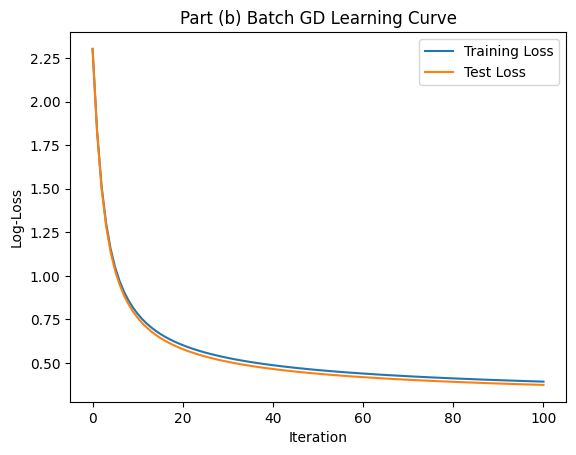

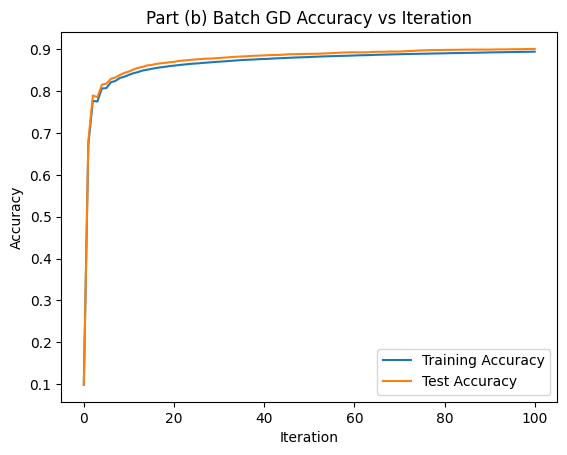

In [11]:
# Part (b): Batch Gradient Descent — lr=0.5
lr = 0.5
W = np.zeros((features, classes))
b = np.zeros(classes)

train_losses, test_losses, train_accs, test_accs = [], [], [], []

for i in range(101):
    train_losses.append(log_loss(X_train, Y_train, W, b))
    test_losses.append(log_loss(X_test, Y_test, W, b))
    train_accs.append(accuracy(X_train, y_train, W, b))
    test_accs.append(accuracy(X_test, y_test, W, b))
    if i < 100:
        dW, db = grad(X_train, Y_train, W, b)
        W -= lr * dW
        b -= lr * db

print("Train Accuracy: " + str(round(train_accs[-1], 4)) + " Loss: " + str(round(train_losses[-1], 5)))
print("Test  Accuracy: " + str(round(test_accs[-1],  4)) + " Loss: " + str(round(test_losses[-1],  5)))

iters = range(101)

plt.figure()
plt.plot(iters, train_losses, label='Training Loss')
plt.plot(iters, test_losses, label='Test Loss')
plt.xlabel('Iteration')
plt.ylabel('Log-Loss')
plt.title('Part (b) Batch GD Learning Curve')
plt.legend()
plt.show()

plt.figure()
plt.plot(iters, train_accs, label='Training Accuracy')
plt.plot(iters, test_accs, label='Test Accuracy')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Part (b) Batch GD Accuracy vs Iteration')
plt.legend()
plt.show()

In [12]:
with h5py.File('weights_softmax.h5', 'w') as hf:
    hf.create_dataset('W', data=W.T)
    hf.create_dataset('b', data=b)
print("Saved weights_softmax.h5")

Saved weights_softmax.h5


Part C

In [14]:
def run_sgd(batch_size, lr_sgd, n_epochs):
    W_s = np.zeros((features, classes))
    b_s = np.zeros(classes)

    sample_counts = [0]
    s_train_losses = [log_loss(X_train, Y_train, W_s, b_s)]
    s_test_losses  = [log_loss(X_test,  Y_test,  W_s, b_s)]
    s_train_accs   = [accuracy(X_train, y_train, W_s, b_s)]
    s_test_accs    = [accuracy(X_test,  y_test,  W_s, b_s)]

    total_seen = 0
    next_record = 5000

    for numss in range(n_epochs):
        idx = np.random.permutation(num_samples)
        i = 0
        while i + batch_size <= num_samples:
            batch = idx[i:i + batch_size]
            dW, db = grad(X_train[batch], Y_train[batch], W_s, b_s)
            W_s -= lr_sgd * dW
            b_s -= lr_sgd * db
            total_seen += batch_size
            i += batch_size
            if total_seen >= next_record:
                sample_counts.append(total_seen)
                s_train_losses.append(log_loss(X_train, Y_train, W_s, b_s))
                s_test_losses.append(log_loss(X_test,  Y_test,  W_s, b_s))
                s_train_accs.append(accuracy(X_train, y_train, W_s, b_s))
                s_test_accs.append(accuracy(X_test,  y_test,  W_s, b_s))
                next_record += 5000

    return sample_counts, s_train_losses, s_test_losses, s_train_accs, s_test_accs

SGD bs=1 Train Accuracy: 0.915 Loss: 0.29789
SGD bs=1 Test  Accuracy: 0.9161 Loss: 0.29443


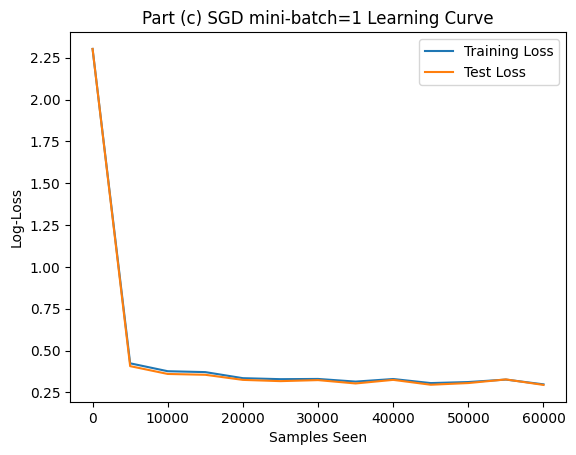

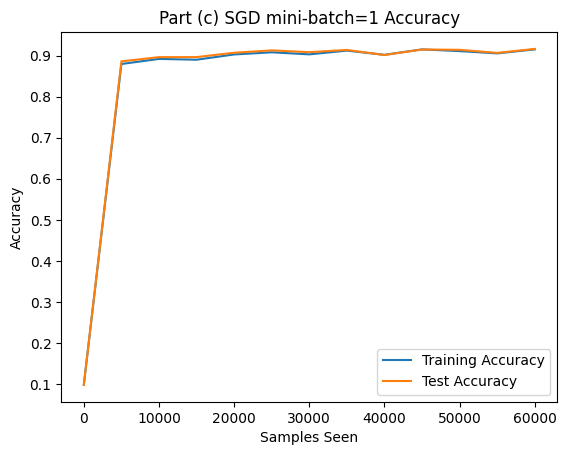

In [19]:
sampleCounts1, trainLoss1, testLoss1, trainAcc1, testAcc1 = run_sgd(batch_size=1, lr_sgd=0.01, n_epochs=1)

print("SGD bs=1 Train Accuracy: " + str(round(trainAcc1[-1], 4)) + " Loss: " + str(round(trainLoss1[-1], 5)))
print("SGD bs=1 Test  Accuracy: " + str(round(testAcc1[-1],  4)) + " Loss: " + str(round(testLoss1[-1],  5)))

plt.figure()
plt.plot(sampleCounts1, trainLoss1, label='Training Loss')
plt.plot(sampleCounts1, testLoss1, label='Test Loss')
plt.xlabel('Samples Seen')
plt.ylabel('Log-Loss')
plt.title('Part (c) SGD mini-batch=1 Learning Curve')
plt.legend()
plt.show()

plt.figure()
plt.plot(sampleCounts1, trainAcc1, label='Training Accuracy')
plt.plot(sampleCounts1, testAcc1, label='Test Accuracy')
plt.xlabel('Samples Seen')
plt.ylabel('Accuracy')
plt.title('Part (c) SGD mini-batch=1 Accuracy')
plt.legend()
plt.show()

SGD bs=100 Train Accuracy: 0.9111 Loss: 0.32065
SGD bs=100 Test  Accuracy: 0.9158 Loss: 0.30964


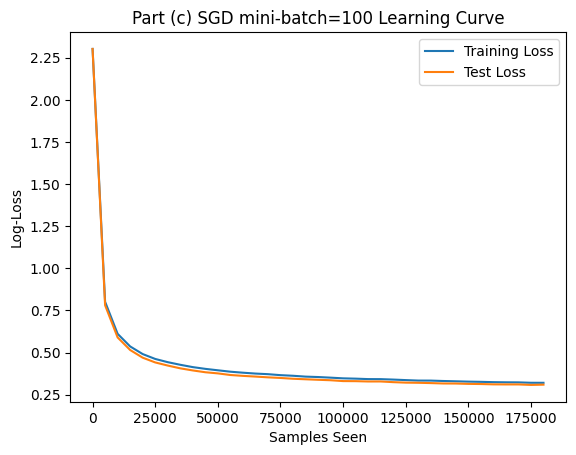

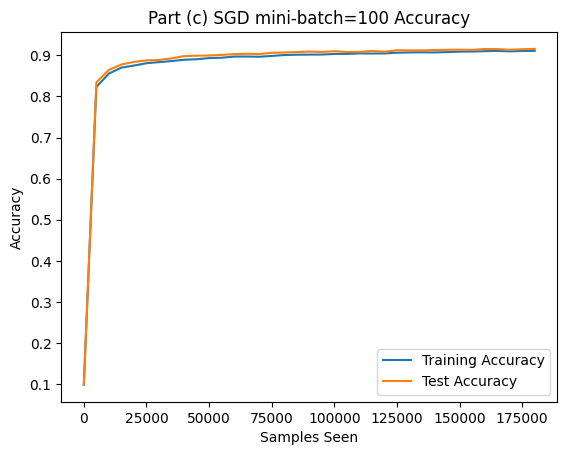

In [20]:
sampleCounts100, trainLoss100, testLoss100, trainAcc100, testAcc100 = run_sgd(batch_size=100, lr_sgd=0.1, n_epochs=3)

print("SGD bs=100 Train Accuracy: " + str(round(trainAcc100[-1], 4)) + " Loss: " + str(round(trainLoss100[-1], 5)))
print("SGD bs=100 Test  Accuracy: " + str(round(testAcc100[-1],  4)) + " Loss: " + str(round(testLoss100[-1],  5)))

plt.figure()
plt.plot(sampleCounts100, trainLoss100, label='Training Loss')
plt.plot(sampleCounts100, testLoss100, label='Test Loss')
plt.xlabel('Samples Seen')
plt.ylabel('Log-Loss')
plt.title('Part (c) SGD mini-batch=100 Learning Curve')
plt.legend()
plt.show()

plt.figure()
plt.plot(sampleCounts100, trainAcc100, label='Training Accuracy')
plt.plot(sampleCounts100, testAcc100, label='Test Accuracy')
plt.xlabel('Samples Seen')
plt.ylabel('Accuracy')
plt.title('Part (c) SGD mini-batch=100 Accuracy')
plt.legend()
plt.show()